In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cwru-bearing-datasets/CWRU_48k_load_1_CNN_data.npz
/kaggle/input/cwru-bearing-datasets/feature_time_48k_2048_load_1.csv
/kaggle/input/cwru-bearing-datasets/raw/IR021_1_214.mat
/kaggle/input/cwru-bearing-datasets/raw/B014_1_190.mat
/kaggle/input/cwru-bearing-datasets/raw/OR007_6_1_136.mat
/kaggle/input/cwru-bearing-datasets/raw/OR014_6_1_202.mat
/kaggle/input/cwru-bearing-datasets/raw/B007_1_123.mat
/kaggle/input/cwru-bearing-datasets/raw/IR007_1_110.mat
/kaggle/input/cwru-bearing-datasets/raw/B021_1_227.mat
/kaggle/input/cwru-bearing-datasets/raw/Time_Normal_1_098.mat
/kaggle/input/cwru-bearing-datasets/raw/OR021_6_1_239.mat
/kaggle/input/cwru-bearing-datasets/raw/IR014_1_175.mat


In [2]:
import scipy.io as sio
import numpy as np
import glob, os, cv2
from scipy.signal import stft

DATA_DIR = '/kaggle/input/cwru-bearing-datasets/raw/'
IMG_SIZE = 224
FS       = 12000
WINDOW   = 2048    # ← changed #0.17 second interval
STEP     = 1024    # ← changed

LABEL_MAP = {
    'Time_Normal': 0,
    'B007': 1, 'B014': 2, 'B021': 3,
    'IR007': 4, 'IR014': 5, 'IR021': 6,
    'OR007': 7, 'OR014': 8, 'OR021': 9
}
CLASS_NAMES = ['Normal','Ball_007','Ball_014','Ball_021',
               'IR_007','IR_014','IR_021',
               'OR_007','OR_014','OR_021']

def get_label(fname):
    for key in LABEL_MAP: 
        if key in fname: return LABEL_MAP[key]
    return -1

def get_de_signal(mat):
    keys = [k for k in mat.keys() if 'DE_time' in k]
    return mat[keys[0]].flatten() if keys else None

def signal_to_spectrogram(signal, fs=FS, nperseg=128, noverlap=64):
    f, t, Zxx  = stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
    magnitude  = np.abs(Zxx) # only magnitude of amplitude remove dir
    log_spec   = 20 * np.log10(magnitude + 1e-10) #convert to decibels
    #Normalize to 0–255: subtract minimum (shift to start at 0), divide by maximum (scale to 0–1), multiply by 255 (to pixel values).
    log_spec  -= log_spec.min()
    log_spec  /= log_spec.max() + 1e-8
    log_spec   = (log_spec * 255).astype(np.uint8)
    #Resize from (65, 31) to (224, 224) so ResNet50 can accept it — ResNet requires exactly 224×224
    img        = cv2.resize(log_spec, (IMG_SIZE, IMG_SIZE))
    return np.stack([img, img, img], axis=-1)

X, y = [], []
for path in sorted(glob.glob(DATA_DIR + '*.mat')):
    mat    = sio.loadmat(path)
    signal = get_de_signal(mat)
    label  = get_label(os.path.basename(path))
    if signal is None or label == -1: continue
    for start in range(0, len(signal) - WINDOW, STEP):
        seg = signal[start:start + WINDOW]
        X.append(signal_to_spectrogram(seg))
        y.append(label)
    print(f"{os.path.basename(path):30s} → {sum(1 for yi in y if yi==label)} spectrograms")

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)
print(f"\nDataset shape: {X.shape}")

# Class balance check
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:12s}: {(y==i).sum()} samples")

B007_1_123.mat                 → 474 spectrograms
B014_1_190.mat                 → 473 spectrograms
B021_1_227.mat                 → 474 spectrograms
IR007_1_110.mat                → 473 spectrograms
IR014_1_175.mat                → 476 spectrograms
IR021_1_214.mat                → 472 spectrograms
OR007_6_1_136.mat              → 474 spectrograms
OR014_6_1_202.mat              → 472 spectrograms
OR021_6_1_239.mat              → 476 spectrograms
Time_Normal_1_098.mat          → 471 spectrograms

Dataset shape: (4735, 224, 224, 3)
  Normal      : 471 samples
  Ball_007    : 474 samples
  Ball_014    : 473 samples
  Ball_021    : 474 samples
  IR_007      : 473 samples
  IR_014      : 476 samples
  IR_021      : 472 samples
  OR_007      : 474 samples
  OR_014      : 472 samples
  OR_021      : 476 samples


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Use pretrained ResNet50 (transfer learning)
base = ResNet50(weights='imagenet', include_top=False,
                input_shape=(224, 224, 3))
base.trainable = False   # freeze base initially

model = models.Sequential([
    base,#newlayers
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Phase 1: train only top layers
history1 = model.fit(X_train, y_train,
                     epochs=10, batch_size=32,
                     validation_split=0.1)

# Phase 2: fine-tune last 30 layers of ResNet
base.trainable = True
for layer in base.layers[:-30]:#except last 30 layers all layers are frozen
    layer.trainable = False #replace conv4 and conv5 with "bearing fault frequency band" and "impulse pattern."

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(X_train, y_train,
                     epochs=10, batch_size=32,
                     validation_split=0.1)

2026-04-25 02:17:01.683764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777083421.864066      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777083421.911622      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777083422.342091      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777083422.342117      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777083422.342119      55 computation_placer.cc:177] computation placer alr

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


I0000 00:00:1777083459.972680     122 service.cc:152] XLA service 0x794b60002f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777083459.972715     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777083461.777003     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


  4/107 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.0944 - loss: 2.7037 

I0000 00:00:1777083465.904783     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


107/107 ━━━━━━━━━━━━━━━━━━━━ 30s 164ms/step - accuracy: 0.0956 - loss: 2.4435 - val_accuracy: 0.1003 - val_loss: 2.3023
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.0922 - loss: 2.3032 - val_accuracy: 0.0871 - val_loss: 2.3031
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.0919 - loss: 2.3027 - val_accuracy: 0.0871 - val_loss: 2.3037
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.0975 - loss: 2.3024 - val_accuracy: 0.0871 - val_loss: 2.3040
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.1030 - loss: 2.3025 - val_accuracy: 0.0871 - val_loss: 2.3042
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.0944 - loss: 2.3023 - val_accuracy: 0.0765 - val_loss: 2.3043
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.1113 - loss: 2.3024 - val_accuracy: 0.0871 - val_loss: 2.3046
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.1075 - loss: 2.3027 - val_accuracy: 0.0

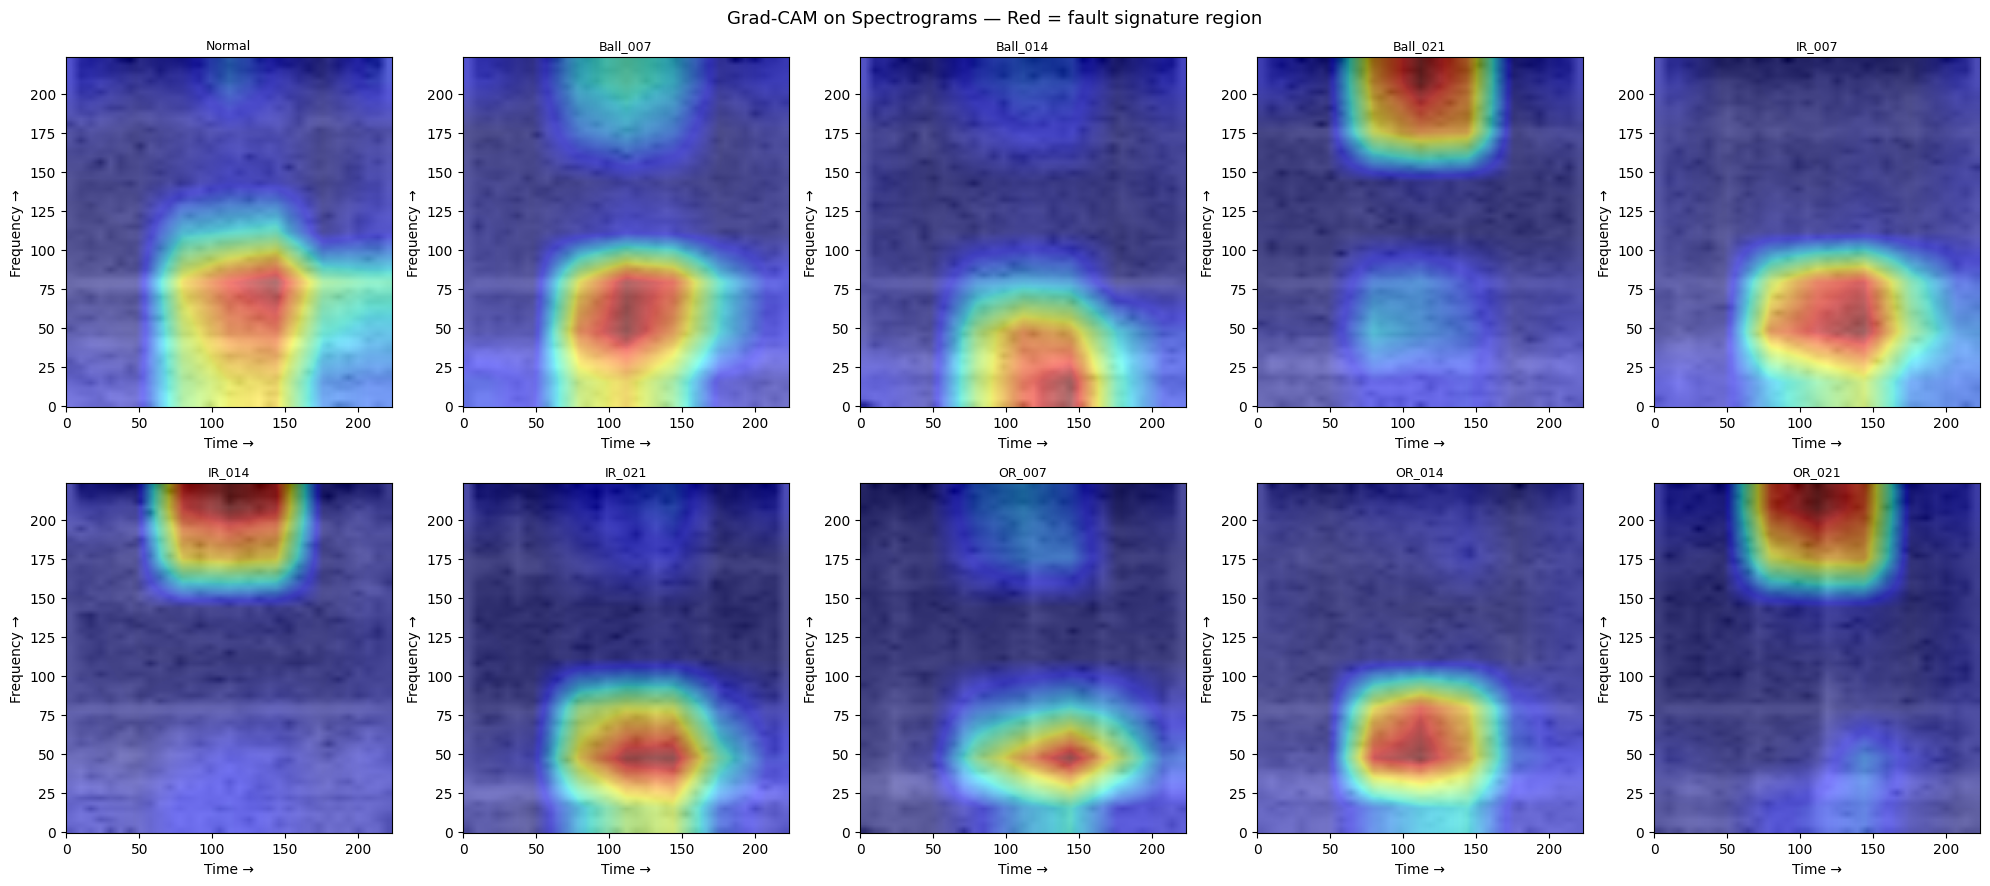

In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def gradcam_2d(model, img_array, class_idx):
    #  Build grad model differently for Keras 3 
    # Get the ResNet base and find last conv layer
    resnet_base = model.layers[0]   # first layer is ResNet50
    
    # Create a new functional model explicitly
    inputs = tf.keras.Input(shape=(224, 224, 3))
    
    # Get last conv output + final predictions
    last_conv_layer   = resnet_base.get_layer('conv5_block3_out')
    last_conv_model   = tf.keras.Model(inputs=resnet_base.input,
                                        outputs=last_conv_layer.output)
    
    with tf.GradientTape() as tape:
        inp          = tf.cast(tf.expand_dims(img_array, 0), tf.float32)
        conv_out     = last_conv_model(inp)
        tape.watch(conv_out)
        
        # Pass conv_out through remaining layers manually
        x = model.layers[1](conv_out)   # GlobalAveragePooling2D
        x = model.layers[2](x)          # Dense 256
        x = model.layers[3](x)          # Dropout
        preds = model.layers[4](x)      # Dense 10 (output)
        loss  = preds[:, class_idx]
    
    grads   = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam     = tf.reduce_sum(weights * conv_out[0], axis=-1).numpy()
    cam     = np.maximum(cam, 0)
    cam    /= (cam.max() + 1e-8)
    cam     = cv2.resize(cam, (224, 224))
    return cam

# Plot: original spectrogram + Grad-CAM overlay
fig, axes = plt.subplots(2, 5, figsize=(20, 9))

for i in range(10):
    idx   = np.where(y_test == i)[0][0]
    img   = X_test[idx]
    cam   = gradcam_2d(model, img, i)
    
    # Overlay heatmap on spectrogram
    heatmap = cm.jet(cam)[..., :3]
    overlay = 0.5 * img + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)
    
    axes.flatten()[i].imshow(overlay, origin='lower', aspect='auto')
    axes.flatten()[i].set_title(CLASS_NAMES[i], fontsize=9)
    axes.flatten()[i].set_xlabel('Time →')
    axes.flatten()[i].set_ylabel('Frequency →')

plt.suptitle('Grad-CAM on Spectrograms — Red = fault signature region', 
             fontsize=13)
plt.tight_layout()
plt.show()

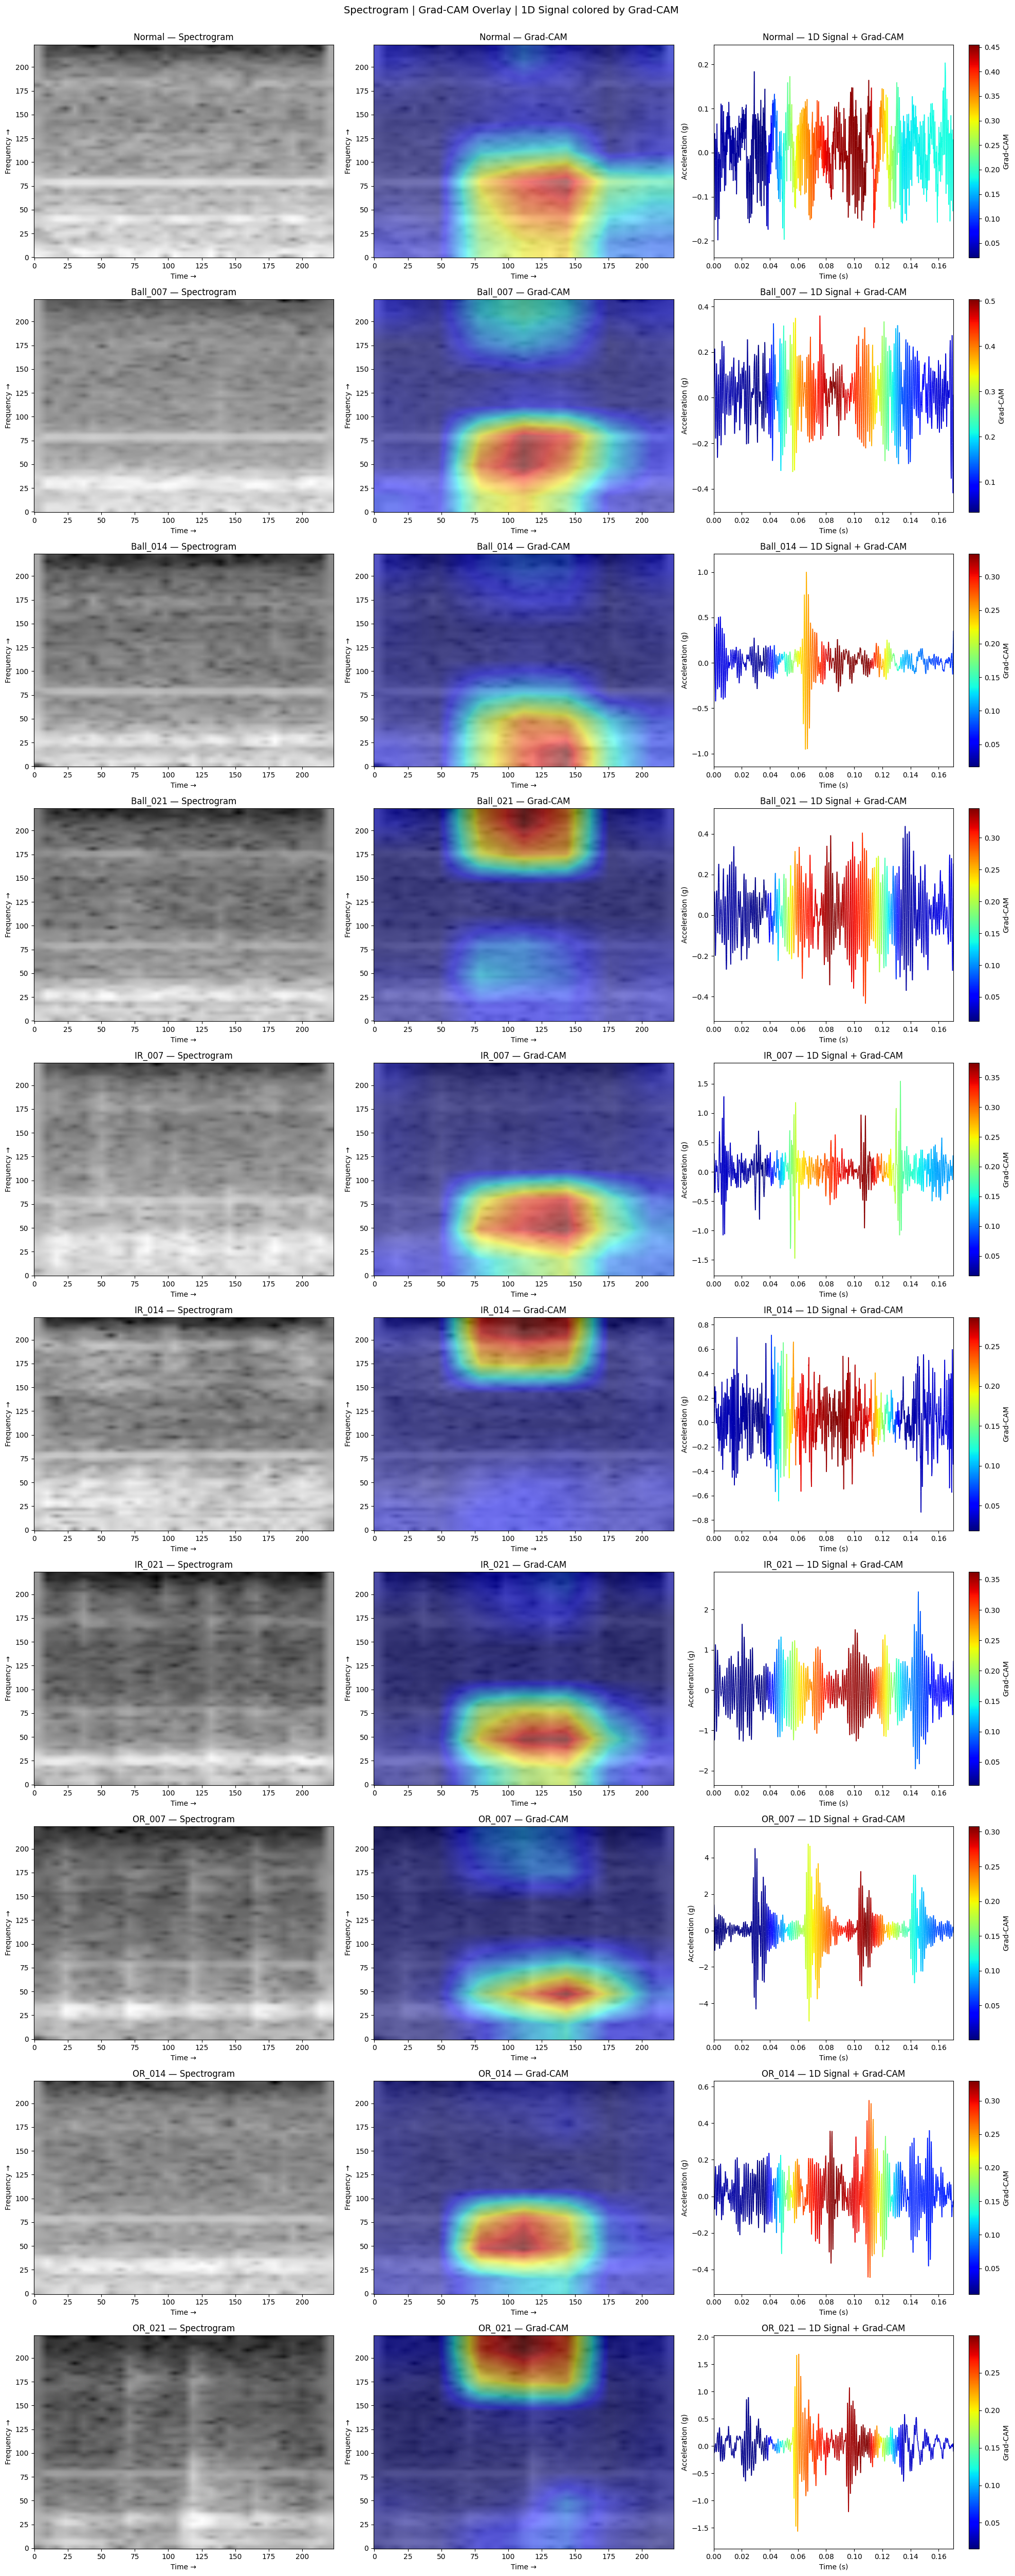

In [5]:
fig, axes = plt.subplots(10, 3, figsize=(20, 50))

for i in range(10):
    idx = np.where(y_test == i)[0][0]
    img = X_test[idx]
    cam = gradcam_2d(model, img, i)

    #  Col 1: Raw spectrogram (no heatmap) 
    axes[i, 0].imshow(img, origin='lower', aspect='auto', cmap='inferno')
    axes[i, 0].set_title(f'{CLASS_NAMES[i]} — Spectrogram')
    axes[i, 0].set_xlabel('Time →')
    axes[i, 0].set_ylabel('Frequency →')

    #  Col 2: Grad-CAM overlay 
    heatmap = cm.jet(cam)[..., :3]
    overlay = np.clip(0.5 * img + 0.5 * heatmap, 0, 1)
    axes[i, 1].imshow(overlay, origin='lower', aspect='auto')
    axes[i, 1].set_title(f'{CLASS_NAMES[i]} — Grad-CAM')
    axes[i, 1].set_xlabel('Time →')
    axes[i, 1].set_ylabel('Frequency →')

    #  Col 3: Reconstructed 1D signal 
    # Re-load the raw signal segment that produced this spectrogram
    mat_files = sorted(glob.glob(DATA_DIR + '*.mat'))
    for path in mat_files:
        if get_label(os.path.basename(path)) == i:
            mat    = sio.loadmat(path)
            signal = get_de_signal(mat)
            seg    = signal[:WINDOW]
            t      = np.arange(WINDOW) / FS

            # Color the 1D signal by Grad-CAM importance
            # Compress 2D cam to 1D by averaging over frequency axis
            cam_1d = cam.mean(axis=0)          # average over freq → time only
            cam_1d = np.interp(                 # stretch to signal length
                np.linspace(0, len(cam_1d)-1, WINDOW),
                np.arange(len(cam_1d)), cam_1d)

            # Plot colored line segments
            from matplotlib.collections import LineCollection
            points  = np.array([t, seg]).T.reshape(-1, 1, 2)
            segs_lc = np.concatenate([points[:-1], points[1:]], axis=1)
            lc      = LineCollection(segs_lc, cmap='jet', linewidth=1.2)
            lc.set_array(cam_1d)
            axes[i, 2].add_collection(lc)
            axes[i, 2].set_xlim(t[0], t[-1])
            axes[i, 2].set_ylim(seg.min()*1.2, seg.max()*1.2)
            plt.colorbar(lc, ax=axes[i, 2], label='Grad-CAM')
            axes[i, 2].set_title(f'{CLASS_NAMES[i]} — 1D Signal + Grad-CAM')
            axes[i, 2].set_xlabel('Time (s)')
            axes[i, 2].set_ylabel('Acceleration (g)')
            break

plt.suptitle('Spectrogram | Grad-CAM Overlay | 1D Signal colored by Grad-CAM',
             fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig('full_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

Accuracy: 0.9456521739130435


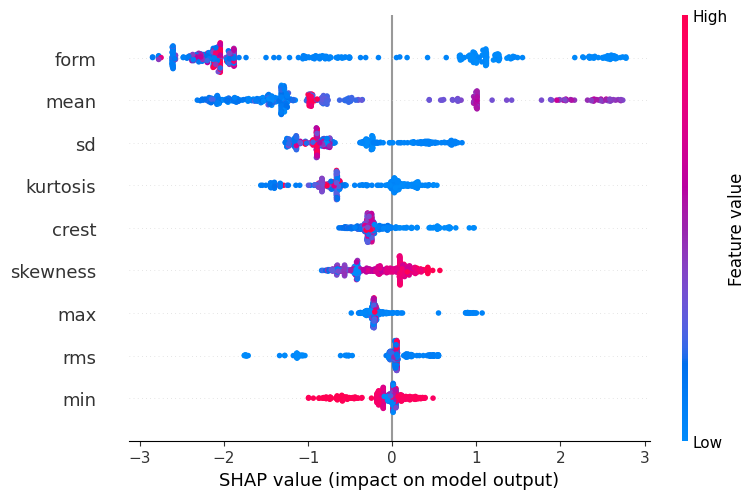

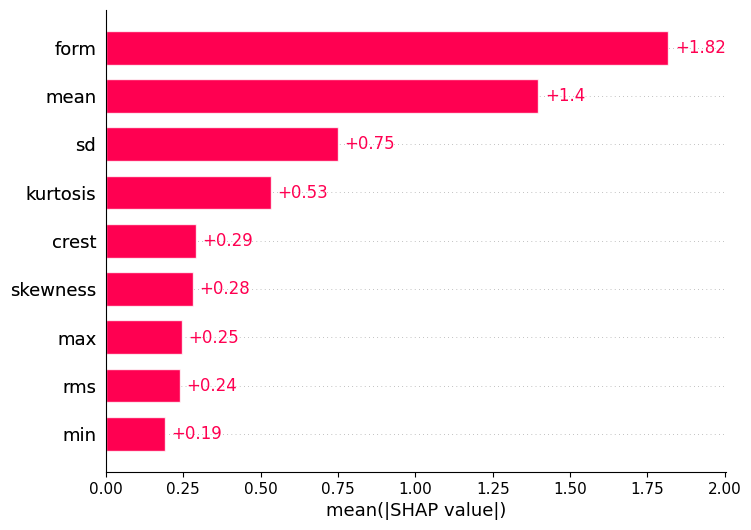

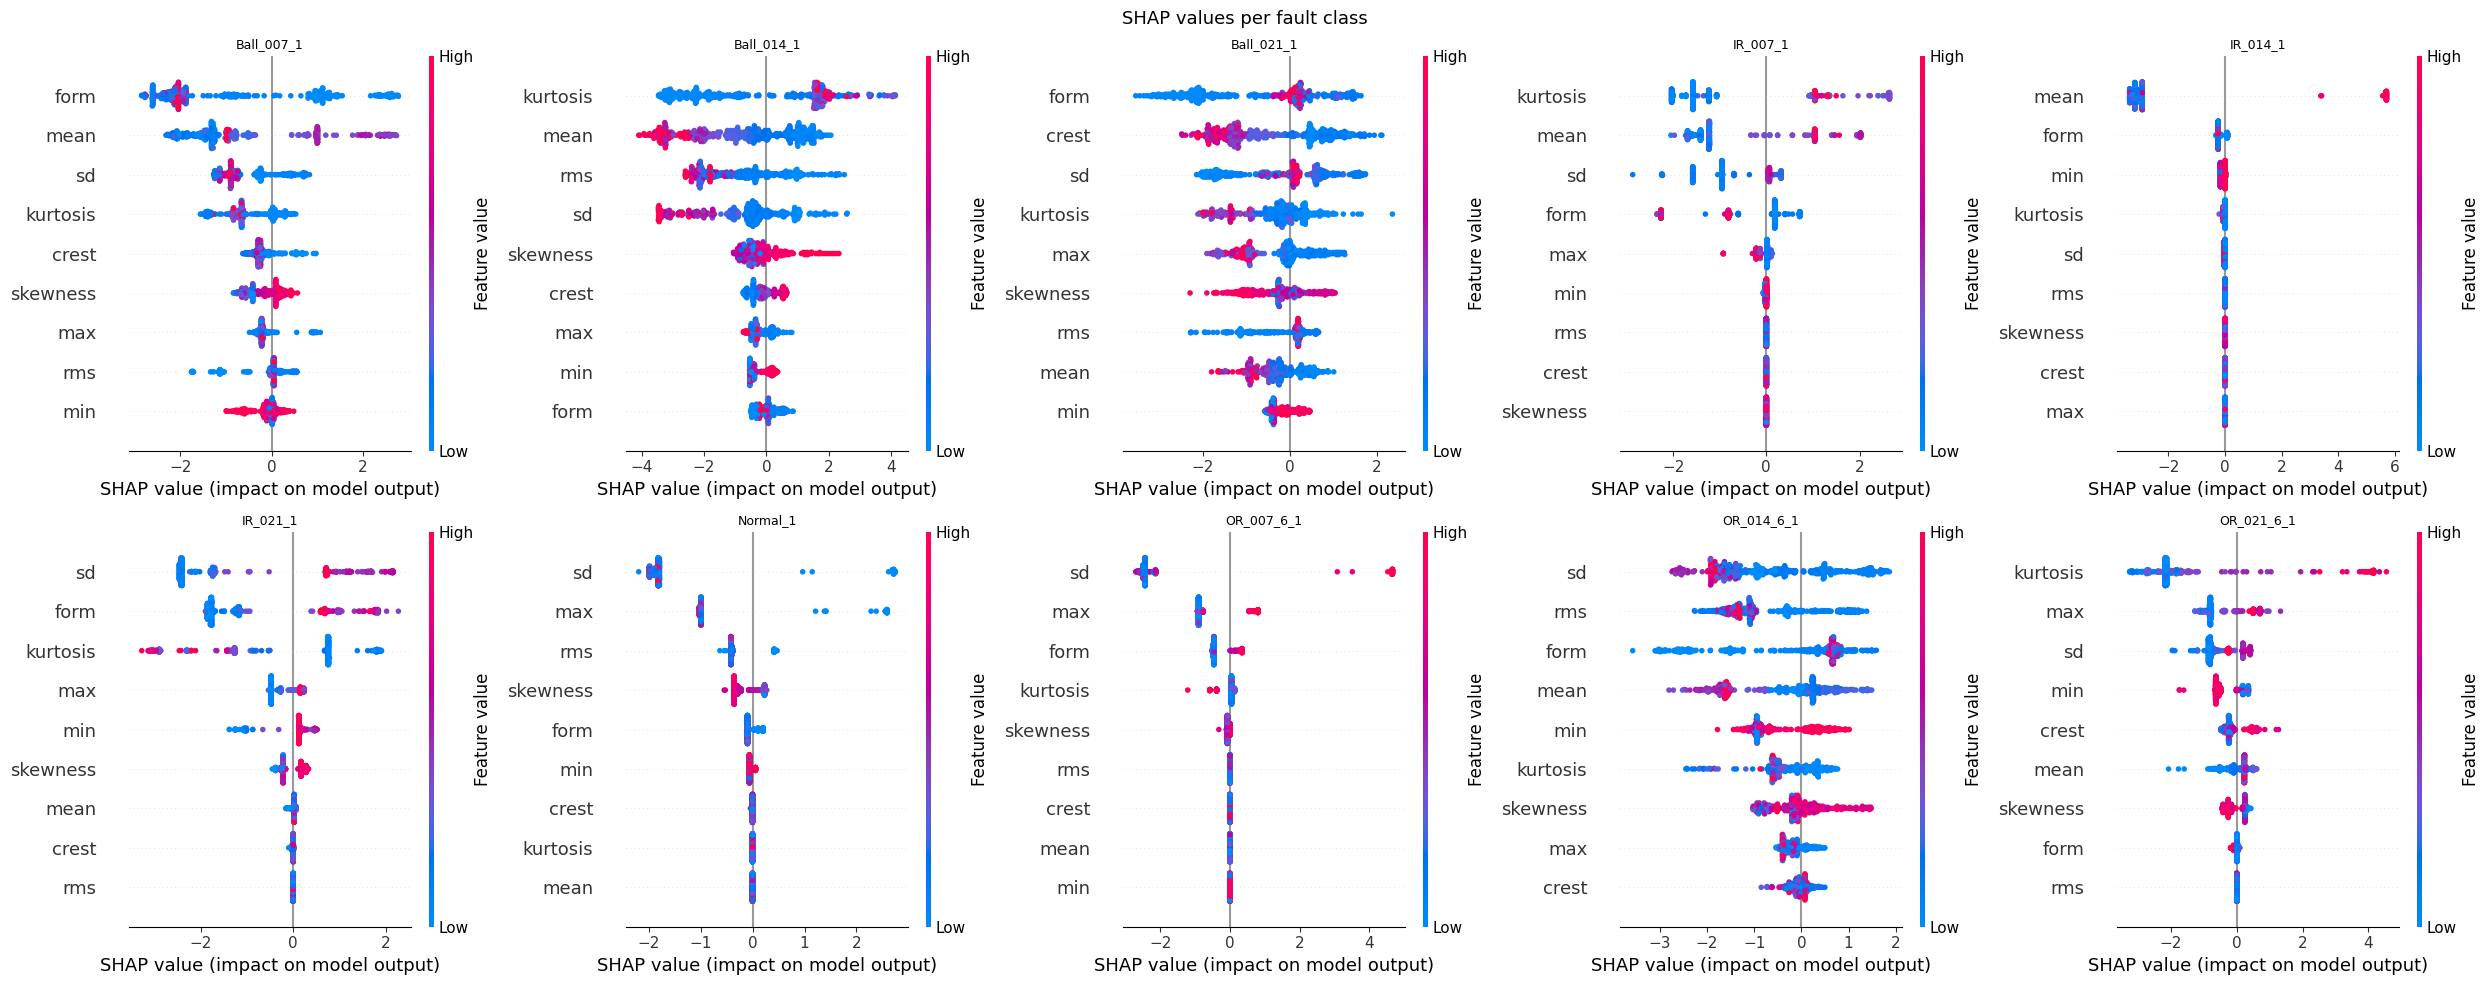

In [6]:
import pandas as pd
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/cwru-bearing-datasets/feature_time_48k_2048_load_1.csv')

le = LabelEncoder()
df['label'] = le.fit_transform(df['fault'])#makes 9 classes

features = ['max','min','mean','sd','rms','skewness','kurtosis','crest','form']
X_feat = df[features]
y_feat = df['label']

X_tr, X_te, y_tr, y_te = train_test_split(X_feat, y_feat,
                                            test_size=0.2, stratify=y_feat, random_state=42)

clf = xgb.XGBClassifier(n_estimators=200, max_depth=5, eval_metric='mlogloss')
clf.fit(X_tr, y_tr)
print("Accuracy:", clf.score(X_te, y_te))

#  Fix: use TreeExplainer with correct output 
explainer = shap.TreeExplainer(clf)
shap_vals = explainer(X_te)          # ← use __call__ not .shap_values()

# Summary plot — one plot per class, or averaged
shap.summary_plot(shap_vals.values[:,:,0], X_te,
                  feature_names=features,
                  plot_type='dot',
                  title='SHAP — Class: Normal')

#  Better: bar chart averaged across all classes 
shap.plots.bar(shap_vals[:,:,0])

#  Per-class beeswarm 
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for class_idx in range(10):
    plt.sca(axes.flatten()[class_idx])
    shap.summary_plot(
        shap_vals.values[:, :, class_idx],
        X_te,
        feature_names=features,
        show=False,
        plot_size=None
    )
    plt.title(le.classes_[class_idx], fontsize=9)

plt.suptitle('SHAP values per fault class', fontsize=13)
plt.tight_layout()
plt.savefig('shap_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# ── Cell A: Fault frequency calculator ────────────────────────────────
import numpy as np

def bearing_fault_freqs(rpm):
    """CWRU 6205-2RS JEM SKF bearing fault frequencies"""
    N     = 9        # number of balls
    d     = 0.3126   # ball diameter (inches)
    D     = 1.748    # pitch diameter (inches)
    alpha = 0        # contact angle (degrees)
    
    s   = rpm / 60   # shaft frequency in Hz
    r   = (d/D) * np.cos(np.radians(alpha))
    
    return {
        'shaft': s,
        'BPFO':  (N/2) * s * (1 - r),        # ball pass outer race
        'BPFI':  (N/2) * s * (1 + r),        # ball pass inner race
        'BSF':   (D/(2*d)) * s * (1 - r**2), # ball spin frequency
        'FTF':   (s/2) * (1 - r),            # fundamental train (cage)
    }

# Print for all 3 load conditions in the dataset
for rpm in [1797, 1772, 1750, 1730]:
    f = bearing_fault_freqs(rpm)
    print(f"\nRPM = {rpm}")
    for name, val in f.items():
        print(f"  {name:6s} = {val:.2f} Hz   "
              f"2x={val*2:.1f}  3x={val*3:.1f}  4x={val*4:.1f}")


RPM = 1797
  shaft  = 29.95 Hz   2x=59.9  3x=89.8  4x=119.8
  BPFO   = 110.67 Hz   2x=221.3  3x=332.0  4x=442.7
  BPFI   = 158.88 Hz   2x=317.8  3x=476.6  4x=635.5
  BSF    = 81.06 Hz   2x=162.1  3x=243.2  4x=324.2
  FTF    = 12.30 Hz   2x=24.6  3x=36.9  4x=49.2

RPM = 1772
  shaft  = 29.53 Hz   2x=59.1  3x=88.6  4x=118.1
  BPFO   = 109.13 Hz   2x=218.3  3x=327.4  4x=436.5
  BPFI   = 156.67 Hz   2x=313.3  3x=470.0  4x=626.7
  BSF    = 79.93 Hz   2x=159.9  3x=239.8  4x=319.7
  FTF    = 12.13 Hz   2x=24.3  3x=36.4  4x=48.5

RPM = 1750
  shaft  = 29.17 Hz   2x=58.3  3x=87.5  4x=116.7
  BPFO   = 107.78 Hz   2x=215.6  3x=323.3  4x=431.1
  BPFI   = 154.72 Hz   2x=309.4  3x=464.2  4x=618.9
  BSF    = 78.94 Hz   2x=157.9  3x=236.8  4x=315.8
  FTF    = 11.98 Hz   2x=24.0  3x=35.9  4x=47.9

RPM = 1730
  shaft  = 28.83 Hz   2x=57.7  3x=86.5  4x=115.3
  BPFO   = 106.55 Hz   2x=213.1  3x=319.6  4x=426.2
  BPFI   = 152.95 Hz   2x=305.9  3x=458.9  4x=611.8
  BSF    = 78.04 Hz   2x=156.1  3x=234.1  4

In [8]:
# ── Cell B: Cyclic Spectral Coherence function ─────────────────────────
from scipy.signal import stft
from scipy.signal.windows import hann
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def cyclic_spectral_coherence(signal, fs, n_fft=512, overlap=0.75):
    """
    Compute Cyclic Spectral Coherence (CSC) map.
    
    Returns:
        alpha_axis : cyclic frequency axis (Hz)  — Y axis
        f_axis     : spectral frequency axis (Hz) — X axis  
        CSC        : 2D coherence matrix, values 0-1
    """
    step    = int(n_fft * (1 - overlap))
    window  = hann(n_fft)
    
    # Step 1: STFT → complex spectrogram
    f_ax, t_ax, Zxx = stft(signal, fs=fs, window=window,
                            nperseg=n_fft, noverlap=n_fft-step)
    # Zxx shape: (n_fft//2+1, n_frames)
    
    n_freqs, n_frames = Zxx.shape
    
    # Step 2: For each cyclic frequency alpha,
    # compute cross-correlation between shifted spectrogram copies
    # alpha = k * (fs / n_frames) for k = 0..n_frames//2
    
    # Use FFT along time axis of |Zxx|² to find cyclic content
    power = np.abs(Zxx) ** 2                           # instantaneous power
    
    # FFT along time axis → gives cyclic spectrum
    cyclic_fft = np.fft.rfft(power, axis=1)            # shape: (n_freqs, n_alpha)
    n_alpha     = cyclic_fft.shape[1]
    alpha_ax    = np.fft.rfftfreq(n_frames, d=1.0/(fs/step))[:n_alpha]
    
    # Step 3: Normalize to get coherence (0 to 1)
    # CSC[f, alpha] = |S_x(f, alpha)|² / (S_x(f,0) * S_x(f+alpha, 0))
    mean_power  = np.mean(power, axis=1, keepdims=True) + 1e-10
    csc         = np.abs(cyclic_fft) / (mean_power * n_frames + 1e-10)
    csc         = np.clip(csc, 0, 1)
    
    return alpha_ax, f_ax, csc


def plot_csc_with_faultlines(signal, fs, rpm, fault_type, title,
                              n_fft=512, max_cyclic_hz=300, max_spectral_hz=3000):
    """
    Plot CSC map with fault frequency lines overlaid.
    fault_type: 'BPFO', 'BPFI', 'BSF', or 'Normal'
    """
    freqs = bearing_fault_freqs(rpm)
    alpha_ax, f_ax, csc = cyclic_spectral_coherence(signal, fs, n_fft=n_fft)
    
    # Crop to useful range
    alpha_mask = alpha_ax <= max_cyclic_hz
    f_mask     = f_ax <= max_spectral_hz
    csc_crop   = csc[f_mask, :][:, alpha_mask]
    alpha_crop = alpha_ax[alpha_mask]
    f_crop     = f_ax[f_mask]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    img = ax.pcolormesh(alpha_crop, f_crop, csc_crop,
                        cmap='inferno', shading='auto', vmin=0, vmax=0.3)
    plt.colorbar(img, ax=ax, label='Coherence (0-1)')
    
    # ── Overlay fault frequency lines ──────────────────────────────────
    colors_map = {'BPFO': 'cyan', 'BPFI': 'lime',
                  'BSF': 'yellow', 'shaft': 'white'}
    
    if fault_type != 'Normal':
        target_freq = freqs[fault_type]
        harmonics   = [target_freq * k for k in range(1, 6)
                       if target_freq * k <= max_cyclic_hz]
        for h, hf in enumerate(harmonics):
            ax.axvline(hf, color='red', linewidth=1.0,
                       linestyle='--', alpha=0.8,
                       label=f'{fault_type} ×{h+1} = {hf:.1f} Hz' if h < 3 else '')
    
    # Always show shaft frequency
    for k in range(1, 4):
        sf = freqs['shaft'] * k
        if sf <= max_cyclic_hz:
            ax.axvline(sf, color='white', linewidth=0.5,
                       linestyle=':', alpha=0.5,
                       label=f'Shaft ×{k}' if k == 1 else '')
    
    ax.set_xlabel('Cyclic frequency α (Hz)  — modulation rate')
    ax.set_ylabel('Spectral frequency f (Hz) — carrier')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8,
              framealpha=0.4, facecolor='black', labelcolor='white')
    plt.tight_layout()
    return fig

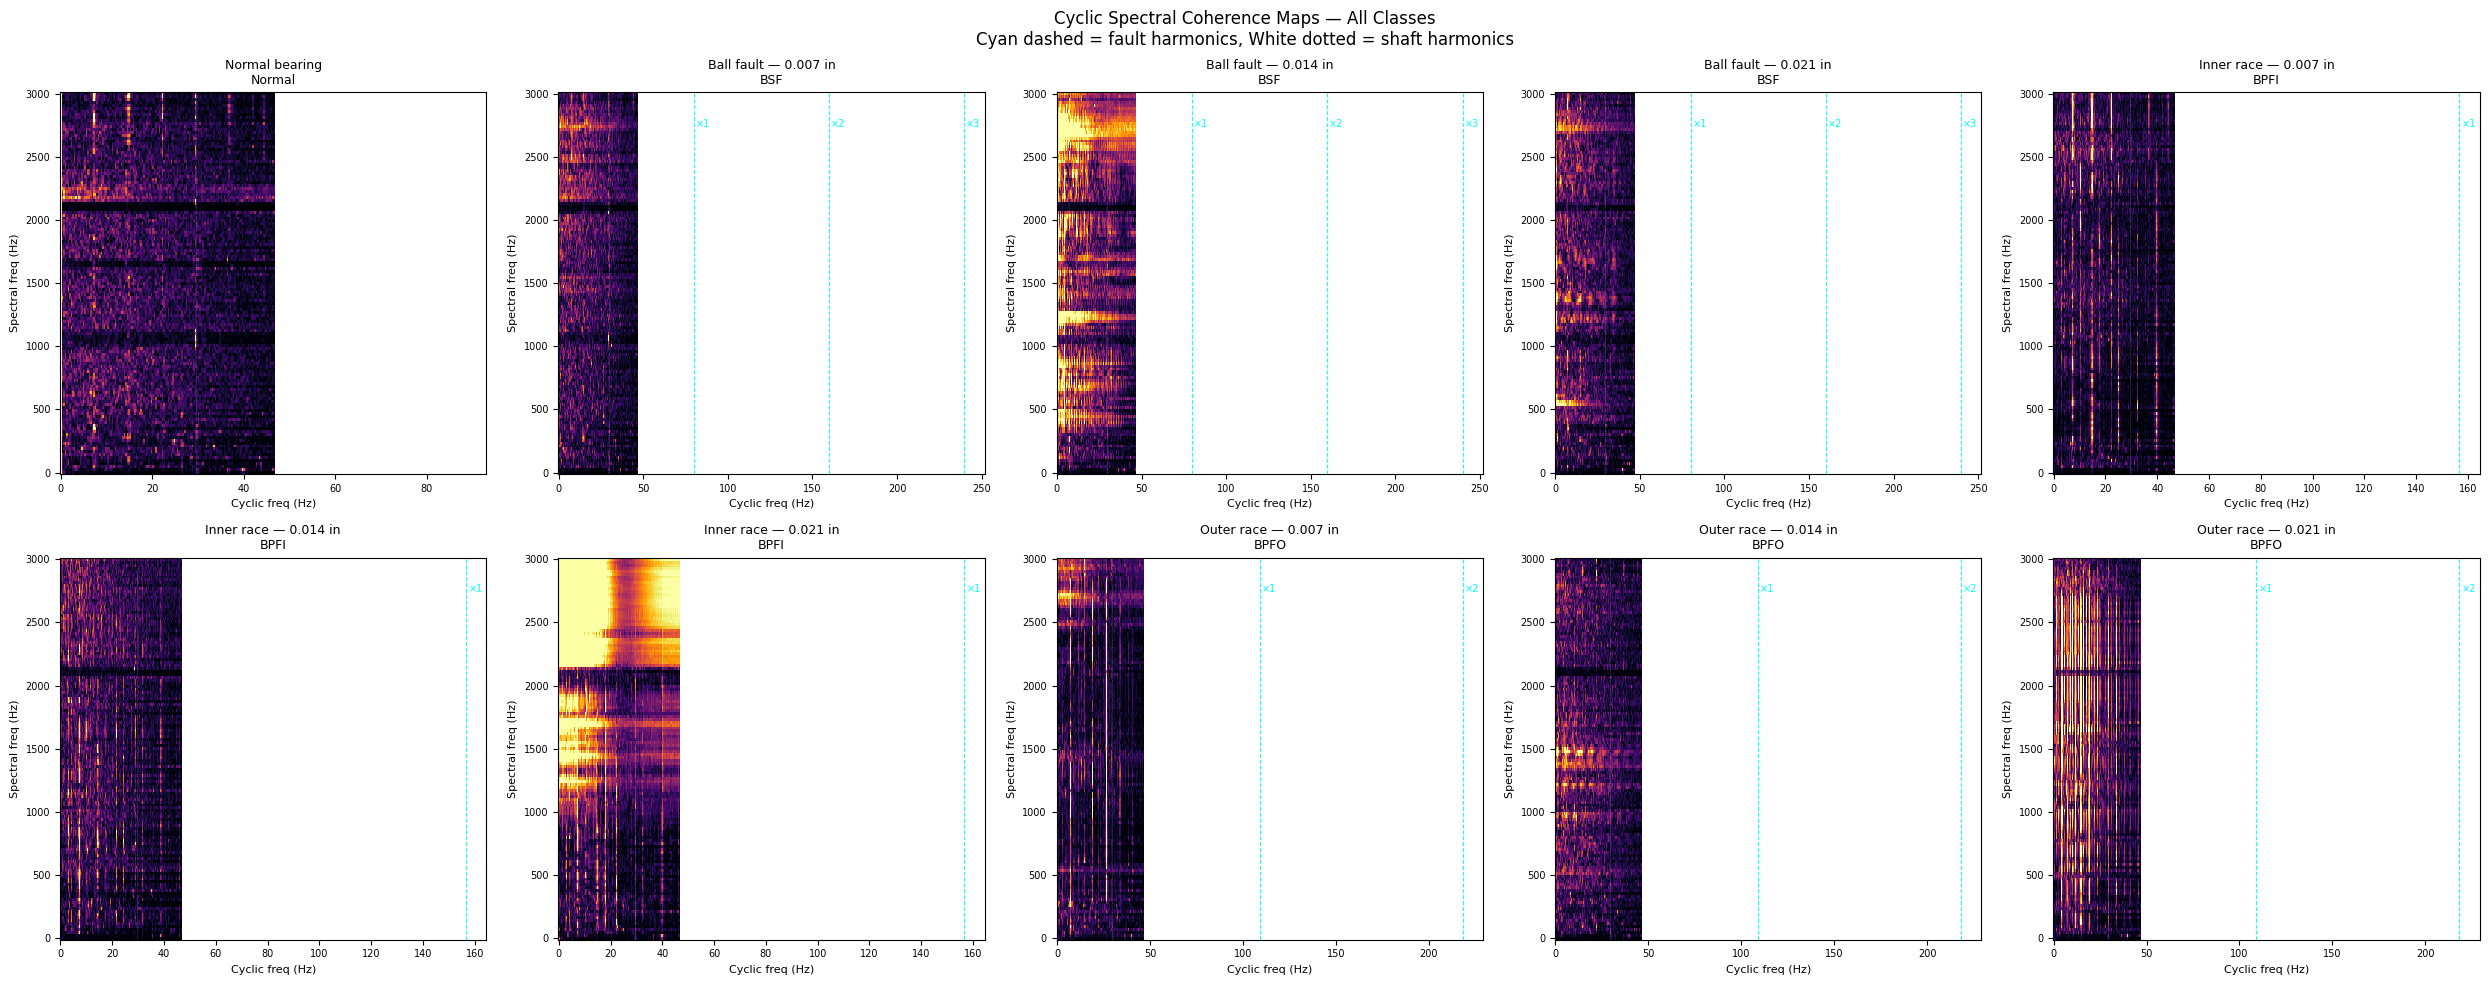

Saved!


In [9]:
# ── Cell C: Generate CSC maps for all 10 classes ───────────────────────
import scipy.io as sio
import glob, os

DATA_DIR = '/kaggle/input/cwru-bearing-datasets/raw/'
FS       = 12000
RPM      = 1772

FILE_CONFIG = {
    'Time_Normal_1_098.mat': ('Normal',  'Normal bearing'),
    'B007_1_123.mat':        ('BSF',     'Ball fault — 0.007 in'),
    'B014_1_190.mat':        ('BSF',     'Ball fault — 0.014 in'),
    'B021_1_227.mat':        ('BSF',     'Ball fault — 0.021 in'),
    'IR007_1_110.mat':       ('BPFI',    'Inner race — 0.007 in'),
    'IR014_1_175.mat':       ('BPFI',    'Inner race — 0.014 in'),
    'IR021_1_214.mat':       ('BPFI',    'Inner race — 0.021 in'),
    'OR007_6_1_136.mat':     ('BPFO',    'Outer race — 0.007 in'),
    'OR014_6_1_202.mat':     ('BPFO',    'Outer race — 0.014 in'),
    'OR021_6_1_239.mat':     ('BPFO',    'Outer race — 0.021 in'),
}

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for idx, (fname, (fault_type, desc)) in enumerate(FILE_CONFIG.items()):
    path = os.path.join(DATA_DIR, fname)
    mat  = sio.loadmat(path)
    
    # Get DE signal, take first 3 seconds only (enough for good CSC)
    keys   = [k for k in mat.keys() if 'DE_time' in k]
    signal = mat[keys[0]].flatten()[:FS*3]
    
    freqs      = bearing_fault_freqs(RPM)
    alpha_ax, f_ax, csc = cyclic_spectral_coherence(signal, FS, n_fft=512)
    
    # Crop
    a_mask = alpha_ax <= 300
    f_mask = f_ax <= 3000
    csc_c  = csc[f_mask, :][:, a_mask]
    
    ax = axes.flatten()[idx]
    ax.pcolormesh(alpha_ax[a_mask], f_ax[f_mask], csc_c,
                  cmap='inferno', shading='auto', vmin=0, vmax=0.3)
    
    # Draw fault frequency lines
    if fault_type != 'Normal':
        target = freqs[fault_type]
        for k in range(1, 5):
            hf = target * k
            if hf <= 300:
                ax.axvline(hf, color='cyan', lw=0.8, ls='--', alpha=0.9)
                ax.text(hf+1, 2800, f'×{k}', color='cyan',
                        fontsize=7, va='top')
    
    # Shaft harmonics
    for k in range(1, 4):
        sf = freqs['shaft'] * k
        if sf <= 300:
            ax.axvline(sf, color='white', lw=0.5, ls=':', alpha=0.4)
    
    ax.set_title(f'{desc}\n{fault_type}', fontsize=9)
    ax.set_xlabel('Cyclic freq (Hz)', fontsize=8)
    ax.set_ylabel('Spectral freq (Hz)', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Cyclic Spectral Coherence Maps — All Classes\n'
             'Cyan dashed = fault harmonics, White dotted = shaft harmonics',
             fontsize=12)
plt.tight_layout()
plt.savefig('csc_maps_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [10]:
# ── Cell D: Use CSC maps as CNN input (instead of STFT spectrogram) ────
def signal_to_csc_image(signal, fs=FS, n_fft=512, img_size=224):
    """Convert 1D signal → CSC map → 224×224 image for CNN"""
    import cv2
    alpha_ax, f_ax, csc = cyclic_spectral_coherence(signal, fs, n_fft=n_fft)
    
    # Crop to meaningful range
    a_mask = alpha_ax <= 300
    f_mask = f_ax  <= 3000
    csc_c  = csc[f_mask, :][:, a_mask]
    
    # Normalize to 0-255
    csc_c -= csc_c.min()
    csc_c /= csc_c.max() + 1e-8
    img = (csc_c * 255).astype(np.uint8)
    img = cv2.resize(img, (img_size, img_size))
    return np.stack([img, img, img], axis=-1)


# Rebuild dataset using CSC instead of STFT
WINDOW, STEP = 12000, 6000  # longer window needed for good CSC freq resolution

X_csc, y_csc = [], []
for path in sorted(glob.glob(DATA_DIR + '*.mat')):
    mat    = sio.loadmat(path)
    keys   = [k for k in mat.keys() if 'DE_time' in k]
    if not keys: continue
    signal = mat[keys[0]].flatten()
    label  = get_label(os.path.basename(path))
    if label == -1: continue
    
    for start in range(0, len(signal) - WINDOW, STEP):
        seg = signal[start:start + WINDOW]
        X_csc.append(signal_to_csc_image(seg))
        y_csc.append(label)
    
    print(f"{os.path.basename(path):30s} → {sum(1 for yi in y_csc if yi==label)} CSC images")

X_csc = np.array(X_csc, dtype=np.float32) / 255.0
y_csc = np.array(y_csc)
print(f"\nCSC dataset: {X_csc.shape}")
# Then feed X_csc, y_csc into the same ResNet50 training code from before

B007_1_123.mat                 → 80 CSC images
B014_1_190.mat                 → 80 CSC images
B021_1_227.mat                 → 80 CSC images
IR007_1_110.mat                → 80 CSC images
IR014_1_175.mat                → 80 CSC images
IR021_1_214.mat                → 79 CSC images
OR007_6_1_136.mat              → 80 CSC images
OR014_6_1_202.mat              → 79 CSC images
OR021_6_1_239.mat              → 80 CSC images
Time_Normal_1_098.mat          → 79 CSC images

CSC dataset: (797, 224, 224, 3)
